# 📓 GitHub Repository Classifier – DistilBERT + Focal Loss


In [1]:
!pip install -q transformers datasets accelerate scikit-learn pandas seaborn matplotlib torch

In [2]:
import os
import re
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

print("✅ تم استيراد جميع المكتبات بنجاح.")

✅ تم استيراد جميع المكتبات بنجاح.


In [3]:
def generate_repo_labels(df):
    """
    Generate labels based on topics with hierarchical priority.
    Priority: AI > Data Science > Mobile > DevOps > Web
    """
    HIERARCHY = ['AI', 'Data Science', 'Mobile', 'DevOps', 'Web']
    FULL_NAMES = {
        'AI': 'AI / Machine Learning',
        'Data Science': 'Data Science',
        'Mobile': 'Mobile Applications',
        'DevOps': 'DevOps',
        'Web': 'Web Development'
    }

    KEYWORDS = {
        'AI': ['machine-learning', 'deep-learning', 'neural-network', 'tensorflow',
               'pytorch', 'llm', 'transformer', 'artificial-intelligence', 'nlp',
               'computer-vision', 'keras', 'scikit-learn'],
        'Data Science': ['data-science', 'pandas', 'numpy', 'data-analysis', 'visualization',
                         'matplotlib', 'jupyter', 'data-mining', 'big-data', 'sql'],
        'Mobile': ['android', 'ios', 'mobile', 'flutter', 'react-native', 'swift',
                   'kotlin', 'xamarin', 'mobile-app'],
        'DevOps': ['docker', 'kubernetes', 'ci-cd', 'devops', 'aws', 'azure', 'gcp',
                   'terraform', 'ansible', 'jenkins', 'cloud', 'infrastructure'],
        'Web': ['react', 'frontend', 'backend', 'web', 'javascript', 'vue', 'angular',
                'nodejs', 'express', 'django', 'flask', 'html', 'css', 'rest-api', 'graphql']
    }

    def classify_row(row):
        topics = row.get('topics_list', [])
        if isinstance(topics, str):
            try:
                import ast
                topics = ast.literal_eval(topics)
            except:
                topics = [t.strip() for t in topics.replace('|', ',').split(',') if t.strip()]

        topics_lower = [t.lower() for t in topics]
        matched = {}

        for cat, kws in KEYWORDS.items():
            count = sum(1 for kw in kws if kw.lower() in topics_lower)
            if count > 0:
                matched[cat] = count

        if not matched:
            return None, 0.0, "No matching topics"

        for priority_cat in HIERARCHY:
            if priority_cat in matched:
                confidence = min(0.95, (matched[priority_cat] / len(KEYWORDS[priority_cat])) * 2 + 0.5)
                reason = f"Matched {matched[priority_cat]} keywords for {FULL_NAMES[priority_cat]}"
                return FULL_NAMES[priority_cat], round(confidence, 2), reason

        return None, 0.0, "No priority match"

    results = df.apply(classify_row, axis=1)
    df['label'] = [r[0] for r in results]
    df['confidence'] = [r[1] for r in results]
    df['reason'] = [r[2] for r in results]

    return df[['name', 'description', 'readme', 'topics_list', 'label', 'confidence', 'reason']]

# Load raw data and apply labeling
df_raw = pd.read_csv('/content/cleaned_data.csv')
df_labeled = generate_repo_labels(df_raw)
df_labeled.dropna(subset=['label'], inplace=True)
print(df_labeled['label'].value_counts())

label
AI / Machine Learning    245
DevOps                   114
Mobile Applications       52
Web Development           34
Data Science              20
Name: count, dtype: int64


/tmp/ipykernel_7534/3136700114.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labeled.dropna(subset=['label'], inplace=True)


In [4]:
def merge_to_3_categories(df_labeled):
    """Merge categories into 3 final classes: AI, Mobile, Web"""
    df_merged = df_labeled.copy()

    # Merge: Data Science → AI / Machine Learning, DevOps → Web Development
    df_merged['label'] = df_merged['label'].replace({
        'Data Science': 'AI / Machine Learning',
        'DevOps': 'Web Development'
    })

    # Define mapping for 3 classes
    label2id = {
        'AI / Machine Learning': 0,
        'Mobile Applications': 1,
        'Web Development': 2
    }
    id2label = {v: k for k, v in label2id.items()}

    # Compute class weights for balanced loss
    from sklearn.utils.class_weight import compute_class_weight
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(df_merged['label']),
        y=df_merged['label']
    )
    class_weight_dict = dict(enumerate(class_weights))

    print("📊 Class distribution after merging (3 classes):")
    print(df_merged['label'].value_counts())
    print(f"\n⚖️ Class weights: {class_weight_dict}")

    # Convert labels to IDs
    df_merged['label_id'] = df_merged['label'].map(label2id)

    # Split 70/15/15
    train_df, temp_df = train_test_split(
        df_merged, test_size=0.30, stratify=df_merged['label'], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
    )

    print(f"\n📈 Final split:")
    print(f"   Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    return train_df, val_df, test_df, label2id, id2label, class_weight_dict

train_df, val_df, test_df, label2id, id2label, class_weights = merge_to_3_categories(df_labeled)

📊 Class distribution after merging (3 classes):
label
AI / Machine Learning    265
Web Development          148
Mobile Applications       52
Name: count, dtype: int64

⚖️ Class weights: {0: np.float64(0.5849056603773585), 1: np.float64(2.980769230769231), 2: np.float64(1.0472972972972974)}

📈 Final split:
   Train: 325 | Val: 70 | Test: 70


In [5]:
def prepare_datasets(train_df, val_df, test_df, tokenizer_name="distilbert-base-uncased", max_length=512):
    """Clean text, tokenize, and convert to Hugging Face Dataset"""
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    def clean_text(text):
        """Remove URLs, Markdown, HTML, code blocks, special chars"""
        if not isinstance(text, str):
            return ""
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'!\[.*?\]\(.*?\)', '', text)
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'```[\s\S]*?```', ' ', text)
        text = re.sub(r'[^\w\s.,!?;:\-\']', ' ', text)
        return re.sub(r'\s+', ' ', text).strip()

    def preprocess(df):
        """Combine description + README and clean"""
        df = df.copy()
        df['clean_text'] = df['description'].fillna('') + " [SEP] " + df['readme'].fillna('')
        df['clean_text'] = df['clean_text'].apply(clean_text)
        return df

    train_df = preprocess(train_df)
    val_df = preprocess(val_df)
    test_df = preprocess(test_df)

    def create_hf_dataset(df):
        """Convert DataFrame to Hugging Face Dataset with tokenization"""
        ds = Dataset.from_pandas(df[['clean_text', 'label_id']])

        def tokenize_function(examples):
            return tokenizer(
                examples['clean_text'],
                truncation=True,
                padding='max_length',
                max_length=max_length
            )

        tokenized = ds.map(tokenize_function, batched=True, remove_columns=['clean_text'])
        return tokenized.rename_column('label_id', 'labels')

    train_dataset = create_hf_dataset(train_df)
    val_dataset = create_hf_dataset(val_df)
    test_dataset = create_hf_dataset(test_df)

    print("✅ Data preparation complete.")
    print(f"   Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

    return train_dataset, val_dataset, test_dataset, tokenizer

train_ds, val_ds, test_ds, tokenizer = prepare_datasets(train_df, val_df, test_df)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/325 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

✅ Data preparation complete.
   Train: 325 | Val: 70 | Test: 70


In [6]:
def setup_standard_model(label2id, id2label, class_weights):
    """Load DistilBERT and convert class weights to tensor"""
    model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    class_weights_tensor = torch.tensor(
        [class_weights[i] for i in range(len(class_weights))],
        dtype=torch.float32
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("✅ Standard model loaded successfully.")
    print(f"   Total parameters: {total_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")
    print(f"   Number of classes: {len(label2id)}")

    return model, class_weights_tensor

model, class_weights_tensor = setup_standard_model(label2id, id2label, class_weights)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Standard model loaded successfully.
   Total parameters: 66,955,779
   Trainable parameters: 66,955,779
   Number of classes: 3


In [7]:
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss to handle severe class imbalance.
    Reduces weight of easy samples, focuses training on hard samples and rare classes.
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Standard cross entropy with class weights (alpha)
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)  # probability of correct class

        # Focal Loss formula: FL = alpha * (1 - pt)^gamma * CE
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

class WeightedTrainer(Trainer):
    """Custom Trainer that injects Focal Loss instead of default Cross-Entropy"""
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = FocalLoss(alpha=self.class_weights.to(logits.device), gamma=2.0)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [8]:
def setup_training_focal(model, train_dataset, val_dataset, class_weights_tensor):
    """Setup training with Focal Loss and early stopping on macro F1"""

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        macro_f1 = f1_score(labels, predictions, average='macro', zero_division=0)
        accuracy = np.mean(predictions == labels)
        return {"f1_macro": macro_f1, "accuracy": accuracy}

    training_args = TrainingArguments(
        output_dir="./distilbert_focal_github",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=20,
        weight_decay=0.05,
        max_grad_norm=1.0,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=True,
        logging_steps=10,
        report_to="none",
        warmup_steps=50,
        save_total_limit=2
    )

    trainer = WeightedTrainer(
        class_weights=class_weights_tensor,
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
    )

    print("✅ Trainer with Focal Loss ready.")
    print("   gamma=2.0 | Focusing on hard samples and minority classes (Mobile/Web)")
    return trainer

trainer = setup_training_focal(model, train_ds, val_ds, class_weights_tensor)

✅ Trainer with Focal Loss ready.
   gamma=2.0 | Focusing on hard samples and minority classes (Mobile/Web)


🚀 Starting training with Focal Loss...



Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.465831,0.557469,0.209150,0.314286
2,0.229660,0.391664,0.443939,0.428571
3,0.246046,0.487726,0.832334,0.885714
4,0.259862,0.348514,0.799418,0.857143
5,0.011035,0.504379,0.855379,0.914286
6,0.011017,0.489795,0.806882,0.857143
7,0.001703,0.545620,0.832020,0.871429
8,0.000890,0.486992,0.834019,0.885714
9,0.000403,0.543626,0.852940,0.900000
10,0.000392,0.527281,0.843047,0.900000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



📊 TRAINING SUMMARY
Total Training Steps: 410
Training Loss: 0.1335

 EVALUATION ON TEST SET



📋 CLASSIFICATION REPORT:
------------------------------------------------------------
                       precision    recall  f1-score   support

AI / Machine Learning       0.89      0.82      0.86        40
  Mobile Applications       1.00      0.62      0.77         8
      Web Development       0.68      0.86      0.76        22

             accuracy                           0.81        70
            macro avg       0.86      0.77      0.80        70
         weighted avg       0.84      0.81      0.82        70


 FINAL METRICS
✅ Macro F1-Score: 0.7955  (primary)
✅ Accuracy: 0.8143  (secondary)


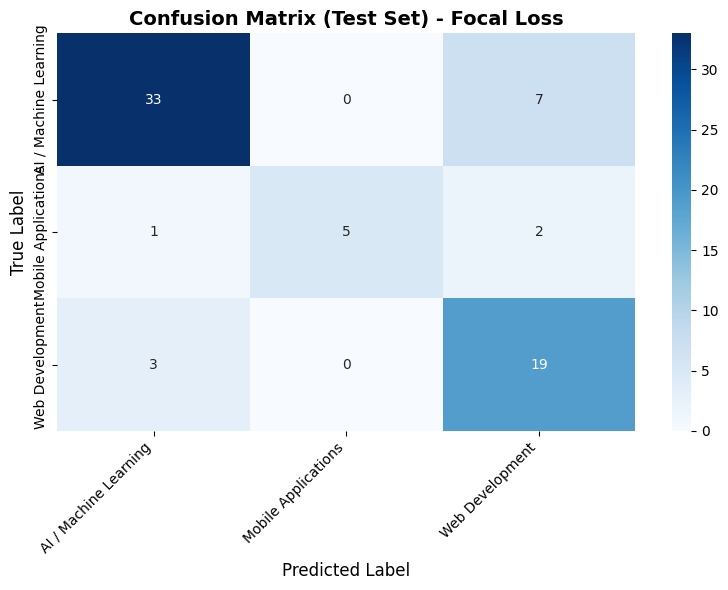

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


💾 Best model saved to: ./best_distilbert_focal_3cats
📈 Best Macro F1 on validation: 0.8554


In [9]:
def train_and_evaluate_final(trainer, test_dataset, id2label):
    """Train with Focal Loss, final evaluation, and display results"""
    print("🚀 Starting training with Focal Loss...\n")
    print("="*60)

    train_result = trainer.train()

    print("\n" + "="*60)
    print("📊 TRAINING SUMMARY")
    print("="*60)
    print(f"Total Training Steps: {train_result.global_step}")
    print(f"Training Loss: {train_result.training_loss:.4f}")

    print("\n" + "="*60)
    print(" EVALUATION ON TEST SET")
    print("="*60)

    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = predictions.label_ids

    target_names = [id2label[i] for i in range(len(id2label))]

    print("\n📋 CLASSIFICATION REPORT:")
    print("-" * 60)
    report = classification_report(y_true, y_pred, target_names=target_names, zero_division=0)
    print(report)

    final_macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    final_accuracy = accuracy_score(y_true, y_pred)

    print("\n" + "="*60)
    print(" FINAL METRICS")
    print("="*60)
    print(f"✅ Macro F1-Score: {final_macro_f1:.4f}  (primary)")
    print(f"✅ Accuracy: {final_accuracy:.4f}  (secondary)")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix (Test Set) - Focal Loss', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Save model and tokenizer
    save_path = "./best_distilbert_focal_3cats"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    print(f"\n💾 Best model saved to: {save_path}")
    print(f"📈 Best Macro F1 on validation: {trainer.state.best_metric:.4f}")

    return final_macro_f1, final_accuracy

final_f1, final_acc = train_and_evaluate_final(trainer, test_ds, id2label)